<a href="https://colab.research.google.com/github/nix-life/Tire-Degradation-AI/blob/main/01_data_exploration_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Collection & Exploration (Google Colab)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]()

---

### ⚠️ Before running anything:

1. **Runtime → Change runtime type → CPU** (data collection doesn't need GPU, saves your GPU quota)
2. **Run the Drive mount cell first** — all files save to your Drive so they survive session restarts
3. FastF1 downloads ~50–200 MB per session on first run. Subsequent runs load from Drive cache.

---

**What this notebook produces (all saved to Google Drive):**
- `f1_rl/data/raw/all_laps.parquet`
- `f1_rl/data/processed/clean_laps.parquet`
- `f1_rl/data/processed/opponent_profiles.pkl`
- `f1_rl/data/processed/pit_losses.json`

**Run notebook 02 after this one completes.**

## 0a. Mount Google Drive

Run this first. All data is saved to Drive so it persists across sessions.
You'll be prompted to authorise access — click the link and paste the code.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Verify mount
import os
print('Drive contents:', os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
Drive contents: ['Classroom', 'Jun 24 wed french work.gdoc', 'Untitled document (16).gdoc', 'Roblox.gdoc', 'Raz Kids: Les microbes : Amis Ou Ennemis July 29 homework.gdoc', 'Essay July 26 homework: what animal whould you like as a pet?.gdoc', "Raz-Kids= L'homme Caribou.gdoc", "L'homme caribou.gdoc", 'natrual disasters.gdoc', 'ArtWork.jpg', 'Untitled document (15).gdoc', 'Would you be a storm chaser?.gdoc', 'Tornadoes and Hurricanes.gdoc', 'IMG_20201002_154758.jpg', 'Volcanoes .gdoc', 'Earthquakes.gdoc', 'Mount St. Helens.gdoc', 'C pour Canada.gdoc', 'IMG_20201023_094653.jpg', 'Untitled document (14).gdoc', 'Brainstorming ideas.gslides', 'Untitled Jam.pdf', 'GOOGLLE DOCS - Bar chart 1.gsheet', 'GOOGLLE DOCS.gdoc', 'Avalanches And Landslides.gdoc', 'Floods and droughts: Compare and contrast.gdoc', "Charlie's French work November 26th .gdoc", 'The most dangerous natural disaster.gdoc', 'Le comparatif page 89-91.gdoc', 'Caribou.gdoc', 'Scoliosis Q&A.gdoc', 'French

## 0b. Install Dependencies

Colab has most packages pre-installed but not FastF1.
This cell only needs to run once per session (not once per notebook restart).

In [ ]:
# Suppress pip output noise
import subprocess, sys

def pip_install(package):
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', '-q', package]
    )

pip_install('fastf1')
pip_install('pyarrow')   # needed for .parquet read/write

# Verify
import fastf1
print(f'FastF1 version: {fastf1.__version__}')

# Check other required packages (pre-installed in Colab)
import pandas, numpy, scipy, sklearn, matplotlib, joblib
print('All dependencies available.')

FastF1 version: 3.8.1
All dependencies available.


## 0c. Setup Project Paths

Everything lives under `MyDrive/f1_rl/`. You can change `PROJECT_ROOT` if you want a different folder name.

In [ ]:
import os

# ── Change this if you want a different Drive folder ──────────────────────
PROJECT_ROOT = '/content/drive/MyDrive/f1_rl'
# ─────────────────────────────────────────────────────────────────────────

PATHS = {
    'raw':             f'{PROJECT_ROOT}/data/raw',
    'cache':           f'{PROJECT_ROOT}/data/raw/fastf1_cache',
    'processed':       f'{PROJECT_ROOT}/data/processed',
    'tyre_models':     f'{PROJECT_ROOT}/data/tyre_models',
    'notebooks':       f'{PROJECT_ROOT}/notebooks',
}

# Create all directories
for name, path in PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f'  OK  {name}: {path}')

print(f'\nProject root: {PROJECT_ROOT}')

  OK  raw: /content/drive/MyDrive/f1_rl/data/raw
  OK  cache: /content/drive/MyDrive/f1_rl/data/raw/fastf1_cache
  OK  processed: /content/drive/MyDrive/f1_rl/data/processed
  OK  tyre_models: /content/drive/MyDrive/f1_rl/data/tyre_models
  OK  notebooks: /content/drive/MyDrive/f1_rl/notebooks

Project root: /content/drive/MyDrive/f1_rl


## 0d. Configure FastF1 Cache

The cache is stored on Drive. This means:
- **First run:** downloads data from the F1 API (slow, ~2–5 min per session)
- **All future runs:** loads from Drive cache (fast, <5 seconds per session)

The cache folder can grow to ~2–4 GB for 3 seasons × 6 circuits. Keep this in mind for Drive storage.

In [ ]:
import fastf1
import warnings
warnings.filterwarnings('ignore')

fastf1.Cache.enable_cache(PATHS['cache'])

# Test that a session loads (small metadata fetch, not full data)
try:
    event = fastf1.get_event(2023, 'Bahrain')
    print(f'FastF1 cache working. Test event: {event["EventName"]} {event["year"]}')
except Exception as e:
    print(f'Cache test failed: {e}')
    print('Check your internet connection and that Drive is mounted.')

Cache test failed: 'year'
Check your internet connection and that Drive is mounted.


## 1. Define Seasons & Circuits

In [ ]:
# Modify these to collect more or fewer circuits/seasons
SEASONS = [2021, 2022, 2023]

# These names must match FastF1's internal event names.
# To verify: fastf1.get_event_schedule(2023)[['EventName','RoundNumber']]
CIRCUITS = [
    'Bahrain',
    'Saudi Arabia',
    'Australia',
    'Japan',
    'Spain',
    'Great Britain',
]

n_sessions = len(SEASONS) * len(CIRCUITS)
print(f'{len(SEASONS)} seasons × {len(CIRCUITS)} circuits = {n_sessions} sessions to collect')
print(f'Estimated first-run time: {n_sessions * 2}–{n_sessions * 5} minutes')
print(f'Estimated cache size: ~{n_sessions * 50}–{n_sessions * 150} MB')

3 seasons × 6 circuits = 18 sessions to collect
Estimated first-run time: 36–90 minutes
Estimated cache size: ~900–2700 MB


## 2. Bulk Lap Collection

⏳ **Slow on first run** — FastF1 fetches from the F1 timing API and caches to Drive.
Subsequent runs load from Drive cache and take seconds instead of minutes.

The cell is resumable — already-cached sessions reload instantly even if a later one fails.

In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm   # Colab-compatible progress bars

def get_track_status_per_lap(session, laps_df):
    """
    Maps FastF1 track status codes to GREEN / VSC / SC for each lap.
    Status codes: 1=Green, 2=Yellow, 4=SC, 6=VSC, 7=Red
    """
    ts = session.track_status
    statuses = []

    for _, lap in laps_df.iterrows():
        lap_start = lap['LapStartTime']
        lap_end   = lap_start + lap['LapTime']

        if pd.isna(lap_start) or pd.isna(lap_end):
            statuses.append('GREEN')
            continue

        mask = (ts['Time'] >= lap_start) & (ts['Time'] < lap_end)
        codes = ts[mask]['Status'].tolist()

        if '4' in codes:
            statuses.append('SC')
        elif '6' in codes:
            statuses.append('VSC')
        else:
            statuses.append('GREEN')

    return statuses


all_laps = []
skipped  = []

for year in tqdm(SEASONS, desc='Season'):
    for circuit in tqdm(CIRCUITS, desc=f'{year}', leave=False):
        try:
            session = fastf1.get_session(year, circuit, 'R')
            session.load(telemetry=False, weather=False, messages=False)

            laps = session.laps.copy()
            laps = laps.dropna(subset=['LapTime', 'Compound', 'TyreLife'])
            laps['TyreLife'] = laps['TyreLife'].fillna(method='ffill')

            laps['Season']      = year
            laps['Circuit']     = circuit
            laps['LapTime_s']   = laps['LapTime'].dt.total_seconds()
            laps['TrackStatus'] = get_track_status_per_lap(session, laps)
            laps['IsPitInLap']  = laps['PitInTime'].notna()
            laps['IsPitOutLap'] = laps['PitOutTime'].notna()

            all_laps.append(laps)
            print(f'  ✓ {year} {circuit} — {len(laps)} laps')

        except Exception as e:
            skipped.append((year, circuit, str(e)))
            print(f'  ✗ {year} {circuit} — {e}')

df_raw = pd.concat(all_laps, ignore_index=True)

# Save to Drive
out_path = f"{PATHS['raw']}/all_laps.parquet"
df_raw.to_parquet(out_path)

print(f'\n✓ Saved {len(df_raw):,} laps → {out_path}')
if skipped:
    print(f'Skipped: {skipped}')

Season:   0%|          | 0/3 [00:00<?, ?it/s]

2021:   0%|          | 0/6 [00:00<?, ?it/s]

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_d

  ✓ 2021 Bahrain — 1018 laps


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

...

  ✓ 2023 Japan — 819 laps


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

  ✓ 2023 Spain — 1312 laps


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cac

  ✓ 2023 Great Britain — 966 laps

✓ Saved 17,828 laps → /content/drive/MyDrive/f1_rl/data/raw/all_laps.parquet


## 3. Inspect Raw Data

In [ ]:
# Reload from Drive in case you're resuming a session
df_raw = pd.read_parquet(f"{PATHS['raw']}/all_laps.parquet")

print(f'Shape: {df_raw.shape}')
print(f'\nCompound distribution:')
print(df_raw['Compound'].value_counts().to_string())
print(f'\nTrack status distribution:')
print(df_raw['TrackStatus'].value_counts().to_string())
print(f'\nLaps per circuit × season:')
print(df_raw.groupby(['Circuit', 'Season']).size().unstack(fill_value=0).to_string())

Shape: (17828, 36)

Compound distribution:
Compound
HARD            6658
MEDIUM          6475
SOFT            4263
INTERMEDIATE     394
WET               38

Track status distribution:
TrackStatus
GREEN    17313
SC         329
VSC        186

Laps per circuit × season:
Season         2021  2022  2023
Circuit                        
Australia      1336  1026   901
Bahrain        1018  1118  1055
Great Britain   925   773   966
Japan          1245   432   819
Saudi Arabia    731   772   924
Spain          1245  1230  1312


## 4. Clean Data

In [ ]:
df = df_raw.copy()
print(f'Starting: {len(df):,} laps')

# 1. Dry compounds only
df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
print(f'After removing wet laps:       {len(df):,}')

# 2. Remove pit laps
df = df[~df['IsPitInLap'] & ~df['IsPitOutLap']]
print(f'After removing pit laps:       {len(df):,}')

# 3. Green flag laps only
df = df[df['TrackStatus'] == 'GREEN']
print(f'After removing SC/VSC laps:    {len(df):,}')

# 4. Impossible lap times
df = df[(df['LapTime_s'] > 60) & (df['LapTime_s'] < 300)]
print(f'After time range filter:       {len(df):,}')

# 5. Per-stint outlier removal (> 107% of median)
def remove_outlier_laps(group):
    median = group['LapTime_s'].median()
    return group[group['LapTime_s'] < median * 1.07]

df = df.groupby(
    ['Season', 'Circuit', 'DriverNumber', 'Compound'],
    group_keys=False
).apply(remove_outlier_laps)

print(f'After outlier removal:         {len(df):,}')
print(f'\nRetained {len(df)/len(df_raw)*100:.1f}% of raw laps')

Starting: 17,828 laps
After removing wet laps:       17,396
After removing pit laps:       16,300
After removing SC/VSC laps:    15,910
After time range filter:       15,910
After outlier removal:         15,109

Retained 84.7% of raw laps


## 5. Normalise Lap Times

In [ ]:
# NormLapTime: ratio to each driver's personal fastest clean lap in that race
df['FastestLap_s'] = df.groupby(
    ['Season', 'Circuit', 'DriverNumber']
)['LapTime_s'].transform('min')

df['NormLapTime'] = df['LapTime_s'] / df['FastestLap_s']

# Stint delta: seconds slower than the first lap of that stint
df = df.sort_values(['Season', 'Circuit', 'DriverNumber', 'LapNumber'])

df['StintID'] = (
    df.groupby(['Season', 'Circuit', 'DriverNumber'])['Compound']
    .transform(lambda x: (x != x.shift()).cumsum())
)

def compute_stint_delta(group):
    group['StintDelta_s'] = group['LapTime_s'] - group['LapTime_s'].iloc[0]
    return group

df = df.groupby(
    ['Season', 'Circuit', 'DriverNumber', 'StintID'],
    group_keys=False
).apply(compute_stint_delta)

print('NormLapTime stats:')
print(df['NormLapTime'].describe().round(4))
print('\nStintDelta_s stats:')
print(df['StintDelta_s'].describe().round(3))

out_path = f"{PATHS['processed']}/clean_laps.parquet"
df.to_parquet(out_path)
print(f'\n✓ Saved → {out_path}')

NormLapTime stats:
count    15109.0000
mean         1.0237
std          0.0173
min          1.0000
25%          1.0104
50%          1.0218
75%          1.0335
max          1.5342
Name: NormLapTime, dtype: float64

StintDelta_s stats:
count    15109.000
mean        -0.992
std          1.873
min        -17.860
25%         -2.106
50%         -0.566
75%          0.193
max          9.239
Name: StintDelta_s, dtype: float64

✓ Saved → /content/drive/MyDrive/f1_rl/data/processed/clean_laps.parquet


## 6. Compute Pit Stop Time Losses

In [ ]:
import json

pit_losses = {}

for circuit, group in df_raw.groupby('Circuit'):
    pit_laps = group[group['IsPitInLap']].copy()

    if len(pit_laps) == 0:
        pit_losses[circuit] = 23.0
        print(f'  {circuit:<18} no pit data — default 23.0s')
        continue

    median_times = (
        group[
            ~group['IsPitInLap'] &
            ~group['IsPitOutLap'] &
            (group['TrackStatus'] == 'GREEN')
        ]
        .groupby('Compound')['LapTime_s']
        .median()
    )

    losses = []
    for _, row in pit_laps.iterrows():
        compound = row['Compound']
        if compound in median_times.index:
            delta = row['LapTime_s'] - median_times[compound]
            if 15 < delta < 45:
                losses.append(delta)

    if losses:
        pit_losses[circuit] = round(float(np.median(losses)), 2)
        print(f'  {circuit:<18} {pit_losses[circuit]:.1f}s  (n={len(losses)} stops)')
    else:
        pit_losses[circuit] = 23.0
        print(f'  {circuit:<18} insufficient data — default 23.0s')

out_path = f"{PATHS['processed']}/pit_losses.json"
with open(out_path, 'w') as f:
    json.dump(pit_losses, f, indent=2)

print(f'\n✓ Saved → {out_path}')

  Australia          17.9s  (n=28 stops)
  Bahrain            26.1s  (n=16 stops)
  Great Britain      29.7s  (n=15 stops)
  Japan              18.0s  (n=32 stops)
  Saudi Arabia       30.8s  (n=25 stops)
  Spain              28.1s  (n=6 stops)

✓ Saved → /content/drive/MyDrive/f1_rl/data/processed/pit_losses.json


## 7. Build Opponent Strategy Profiles

In [ ]:
import joblib

def extract_strategy_profiles(raw_laps_df, circuit):
    circuit_data = raw_laps_df[
        (raw_laps_df['Circuit'] == circuit) &
        (raw_laps_df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']))
    ].copy()

    profiles = []

    for (season, driver), driver_laps in circuit_data.groupby(['Season', 'DriverNumber']):
        driver_laps = driver_laps.sort_values('LapNumber')

        if len(driver_laps) < 10:
            continue

        driver_laps = driver_laps.copy()
        driver_laps['CompoundChanged'] = (
            driver_laps['Compound'] != driver_laps['Compound'].shift(1)
        )
        driver_laps.iloc[0, driver_laps.columns.get_loc('CompoundChanged')] = True

        stint_starts      = driver_laps[driver_laps['CompoundChanged']]
        compound_sequence = stint_starts['Compound'].tolist()
        pitstop_laps      = stint_starts['LapNumber'].tolist()[1:]

        if len(compound_sequence) < 2:
            continue

        profiles.append({
            'start_compound':    compound_sequence[0],
            'compound_sequence': compound_sequence,
            'pitstop_laps':      [int(l) for l in pitstop_laps],
            'n_stops':           len(pitstop_laps),
            'season':            season,
        })

    return profiles


all_profiles = {}

for circuit in CIRCUITS:
    profiles = extract_strategy_profiles(df_raw, circuit)
    all_profiles[circuit] = profiles

    if profiles:
        stops_dist = pd.Series([p['n_stops'] for p in profiles]).value_counts().sort_index()
        print(f'  {circuit:<18} {len(profiles)} profiles — stops: {stops_dist.to_dict()}')
    else:
        print(f'  {circuit:<18} ⚠ NO PROFILES — check data')

out_path = f"{PATHS['processed']}/opponent_profiles.pkl"
joblib.dump(all_profiles, out_path)
print(f'\n✓ Saved → {out_path}')

  Bahrain            58 profiles — stops: {1: 19, 2: 32, 3: 6, 5: 1}
  Saudi Arabia       52 profiles — stops: {1: 45, 2: 6, 3: 1}
  Australia          55 profiles — stops: {1: 50, 2: 4, 4: 1}
  Japan              38 profiles — stops: {1: 21, 2: 16, 3: 1}
  Spain              59 profiles — stops: {1: 16, 2: 37, 3: 5, 4: 1}
  Great Britain      53 profiles — stops: {1: 34, 2: 17, 3: 2}

✓ Saved → /content/drive/MyDrive/f1_rl/data/processed/opponent_profiles.pkl


## 8. Verify All Outputs

In [ ]:
files_to_check = [
    f"{PATHS['raw']}/all_laps.parquet",
    f"{PATHS['processed']}/clean_laps.parquet",
    f"{PATHS['processed']}/pit_losses.json",
    f"{PATHS['processed']}/opponent_profiles.pkl",
]

print('=== Output File Check ===')
all_ok = True
for path in files_to_check:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f'  ✓  {os.path.basename(path):<35}  {size_mb:.1f} MB')
    else:
        print(f'  ✗  {os.path.basename(path):<35}  MISSING')
        all_ok = False

print()
if all_ok:
    print('✓ All files saved to Google Drive.')
    print('  → Open notebook 02_tyre_model_fitting_colab.ipynb next.')
else:
    print('✗ Missing files — re-run the relevant cells above.')

# Sample profile check
profiles = joblib.load(f"{PATHS['processed']}/opponent_profiles.pkl")
circuit  = list(profiles.keys())[0]
print(f'\nSample profile from {circuit}:')
print(profiles[circuit][0])

=== Output File Check ===
  ✓  all_laps.parquet                     1.3 MB
  ✓  clean_laps.parquet                   1.4 MB
  ✓  pit_losses.json                      0.0 MB
  ✓  opponent_profiles.pkl                0.0 MB

✓ All files saved to Google Drive.
  → Open notebook 02_tyre_model_fitting_colab.ipynb next.

Sample profile from Bahrain:
{'start_compound': 'MEDIUM', 'compound_sequence': ['MEDIUM', 'HARD', 'MEDIUM', 'HARD'], 'pitstop_laps': [5, 20, 40], 'n_stops': 3, 'season': np.int64(2021)}


## 9. Optional: Exploratory Plots

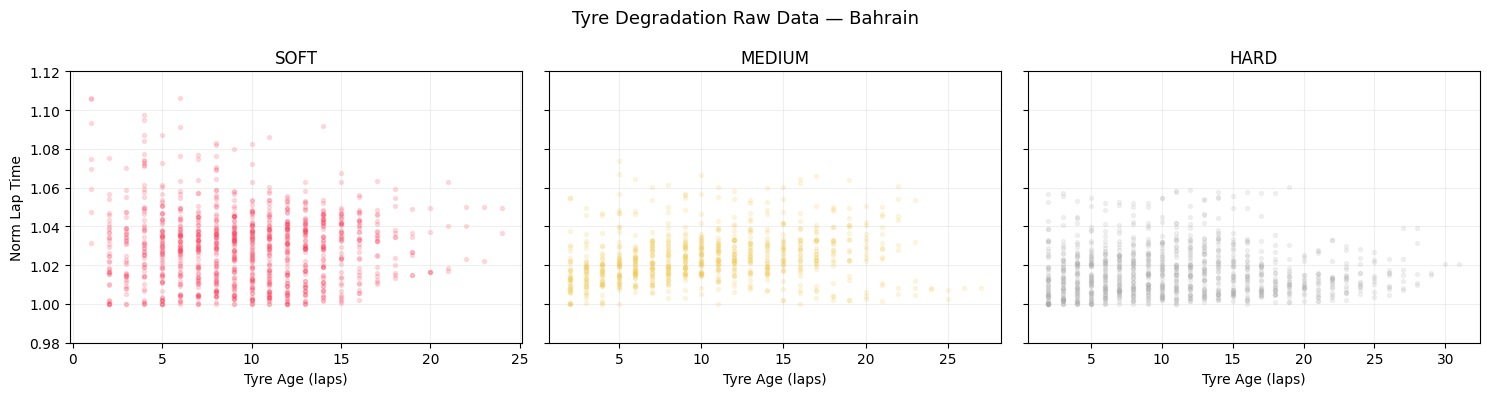

✓ Plot saved → /content/drive/MyDrive/f1_rl/data/processed/degradation_scatter.png


In [ ]:
import matplotlib.pyplot as plt

df_clean = pd.read_parquet(f"{PATHS['processed']}/clean_laps.parquet")

CIRCUIT_TO_PLOT = CIRCUITS[0]  # Change to any circuit in your list

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(f'Tyre Degradation Raw Data — {CIRCUIT_TO_PLOT}', fontsize=13)

COLORS = {'SOFT': '#FF2D4E', 'MEDIUM': '#F5C842', 'HARD': '#AAAAAA'}

for ax, compound in zip(axes, ['SOFT', 'MEDIUM', 'HARD']):
    subset = df_clean[
        (df_clean['Circuit'] == CIRCUIT_TO_PLOT) &
        (df_clean['Compound'] == compound)
    ]
    ax.scatter(
        subset['TyreLife'], subset['NormLapTime'],
        alpha=0.15, s=8, c=COLORS[compound]
    )
    ax.set_xlabel('Tyre Age (laps)')
    ax.set_ylabel('Norm Lap Time' if compound == 'SOFT' else '')
    ax.set_title(compound)
    ax.set_ylim(0.98, 1.12)
    ax.grid(alpha=0.2)

plt.tight_layout()

# Save to Drive
plot_path = f"{PATHS['processed']}/degradation_scatter.png"
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Plot saved → {plot_path}')

## 10. Session Resume Helper

Colab sessions disconnect after ~90 minutes of inactivity. Run this cell at the start of any resumed session to reload all variables without re-downloading data.

In [ ]:
# ── Run this cell to restore variables after a session restart ────────────
# (Drive will already be mounted if you ran the mount cell above)

import pandas as pd
import numpy as np
import joblib, json, os

PROJECT_ROOT = '/content/drive/MyDrive/f1_rl'
PATHS = {
    'raw':         f'{PROJECT_ROOT}/data/raw',
    'cache':       f'{PROJECT_ROOT}/data/raw/fastf1_cache',
    'processed':   f'{PROJECT_ROOT}/data/processed',
    'tyre_models': f'{PROJECT_ROOT}/data/tyre_models',
}

CIRCUITS  = ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'Spain', 'Great Britain']
SEASONS   = [2021, 2022, 2023]

df_raw    = pd.read_parquet(f"{PATHS['raw']}/all_laps.parquet")
df        = pd.read_parquet(f"{PATHS['processed']}/clean_laps.parquet")
pit_losses= json.load(open(f"{PATHS['processed']}/pit_losses.json"))
profiles  = joblib.load(f"{PATHS['processed']}/opponent_profiles.pkl")

print(f'Restored: {len(df_raw):,} raw laps, {len(df):,} clean laps')
print(f'Pit losses loaded for: {list(pit_losses.keys())}')
print(f'Profiles loaded for:   {list(profiles.keys())}')

Restored: 17,828 raw laps, 15,109 clean laps
Pit losses loaded for: ['Australia', 'Bahrain', 'Great Britain', 'Japan', 'Saudi Arabia', 'Spain']
Profiles loaded for:   ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'Spain', 'Great Britain']
